In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## first, lets code the LIF and Fitzhugh Nagumo Model

In [211]:
def lif_plain(t_end, t_step, v_0, I):
    len_t = int(t_end/t_step)
    t = np.linspace(0,t_end, len_t+1)
    v = np.zeros(len_t+1)
    v[0] = v_0
    
    for s in range(1,len(t)):
        if v[s-1] > 1:
            v[s] = 0
        else:
            dv_dt = -1*v[s-1] + I
            v[s] = v[s-1] + t_step*dv_dt
    return t, v

In [213]:
def fitz_plain(t_end, t_step, v_0, w_0):
    len_t = int(t_end/t_step)
    t = np.linspace(0,t_end, len_t+1)
    v = np.zeros(len_t+1)
    w = np.zeros(len_t+1)
    s_times = [0]
    prev_time = 0

    v[0] = v_0
    w[0] = w_0

    for s in range(1,len(t)):
        dv_dt = v[s-1] - v[s-1]**3/3 - w[s-1] + .5
        # print(dv_dt)
        v[s] = v[s-1] + t_step*dv_dt

        dw_dt = 0.08*(v[s-1] + .7 - .8*w[s-1])
        w[s] = w[s-1] + t_step*dw_dt

        if v[s-1] < 0 < v[s]:
            print("Spike occured at time", t[s])
            period = t[s] - prev_time
            s_times = s_times + [period]
            prev_time = t[s]

    return t, v, w, s_times

In [197]:
t_fitz, v_fitz, w_fitz, s_times = fitz_plain(400, .001, 0, 0)

Spike occured at time 38.928
Spike occured at time 78.403
Spike occured at time 117.878
Spike occured at time 157.353
Spike occured at time 196.828
Spike occured at time 236.303
Spike occured at time 275.779
Spike occured at time 315.254
Spike occured at time 354.729
Spike occured at time 394.204


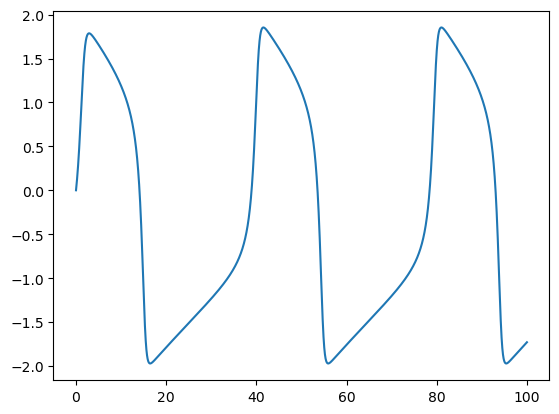

In [137]:
plt.plot(t_fitz, v_fitz)
plt.show()

In [55]:
t_lif, v_lif = lif(5, .01, 0, 1.5)

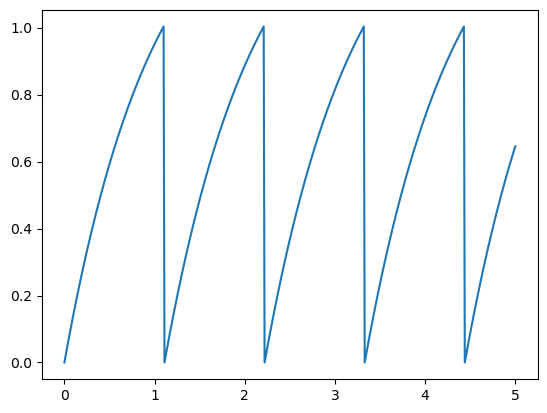

In [57]:
plt.plot(t_lif, v_lif)
plt.show()

In [57]:
period_lif = np.log(1.5/.5)

In [51]:
def lif(t_end, t_step, v_0, I, phi, delta):
    # at time phi, we will spike the system by delta
    spiked = 0 
    len_t = int(t_end/t_step)
    t = np.linspace(0,t_end, len_t+1)
    v = np.zeros(len_t+1)
    v[0] = v_0
    
    for s in range(1,len(t)):
        if v[s-1] > 1:
            # record spike time and return
            s_time = t[s-1]
            return s_time
        else:
            dv_dt = -1*v[s-1] + I
            v[s] = v[s-1] + t_step*dv_dt

        if t[s-1] <= phi < t[s]:
            #print("Neuron voltage perturbed at", t[s-1])
            v[s] += delta

    print("No spikes recorded, something is probably wrong")
    return None

In [53]:
lif(10, .00001, 0, 1.5, .9, .001)

1.0969710969710968

In [59]:
phi_vals = np.linspace(0, period_lif, 100)[:-1]
r_phi_lif = [(period_lif - lif(10,.00001, 0, 1.5, phi, .001))/(period_lif*.001) for phi in phi_vals]

In [61]:
r_phi_theo = [np.e**phi/(period_lif*1.5) for phi in phi_vals]

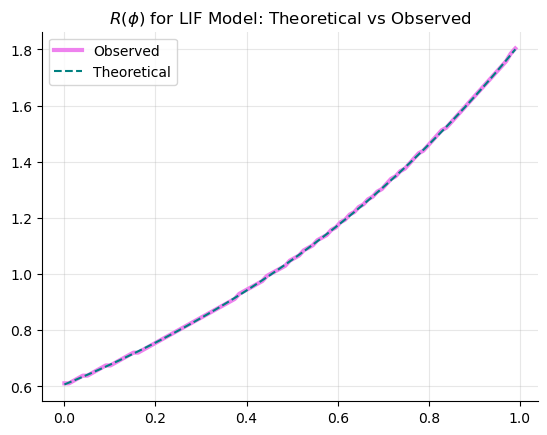

In [63]:
plt.plot(phi_vals/period_lif, r_phi_lif,
         "-",
         linewidth = 3,
         color = "violet",  
         label = "Observed")
plt.plot(phi_vals/period_lif, r_phi_theo, 
         linestyle = "--", 
         color = "teal", 
         label = "Theoretical")

plt.title(r"$R(\phi)$ for LIF Model: Theoretical vs Observed")
plt.grid(alpha = .3)
plt.legend()
sns.despine()
plt.savefig("lif_rcurve.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [11]:
# for fitzhugh nagumo model a spike is defined when voltage crosses zero. 
def fitz(t_end, t_step, v_0, w_0, phi, delta):
    # initialize arrays to keep track
    len_t = int(t_end/t_step)
    t = np.linspace(0,t_end, len_t+1)
    v = np.zeros(len_t+1)
    w = np.zeros(len_t+1)

    # initialize other stuff
    first_spike = 0
    phi_time = None
    v[0] = v_0
    w[0] = w_0

    for s in range(1,len(t)):
        dv_dt = v[s-1] - v[s-1]**3/3 - w[s-1] + .5
        # print(dv_dt)
        v[s] = v[s-1] + t_step*dv_dt

        dw_dt = 0.08*(v[s-1] + .7 - .8*w[s-1])
        w[s] = w[s-1] + t_step*dw_dt

        # track first spike time
        if v[s-1] < 0 < v[s]:
            # we want to perturb the system in the second cycle
            if first_spike == 0:
                first_spike = t[s]
                # print("First spike at t = ", t[s])
                phi_time = phi + first_spike
            else: 
                # print("Second spike(perturbed) at t = ", t[s])
                return t[s] - first_spike

        # perturb system
        if phi_time != None:
            if t[s-1] <= phi_time < t[s]:
                #print("Neuron voltage perturbed at", t[s-1])
                v[s] += delta

    print("No second spike, something went wrong")
    return None

In [13]:
fitz(200, .0001, 0, 0, 15, .001)

39.4751

In [15]:
# empirically calculated period for fn model
period_fn = 39.475
phi_vals2 = np.linspace(0, period_fn, 100)[0:-1]

In [17]:
r_phi = [(period_fn - fitz(100,.0001, 0, 0, phi, .001))/(period_fn*.001) for phi in phi_vals2]

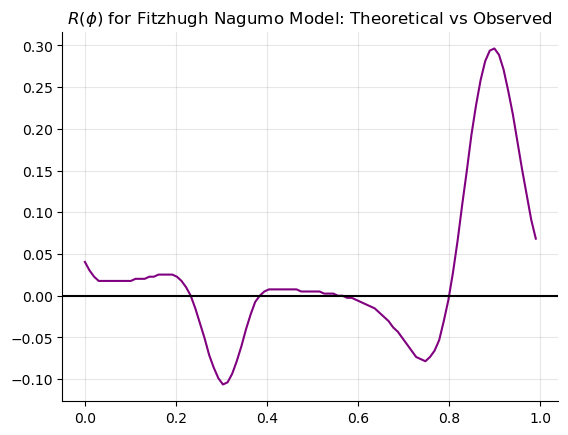

In [47]:
plt.plot(phi_vals2/period_fn, r_phi, color = "purple")
plt.title(r"$R(\phi)$ for Fitzhugh Nagumo Model: Theoretical vs Observed")
plt.axhline(y = 0, color = "black")
plt.grid(alpha = .3)
sns.despine()
plt.savefig("fn_rcurve.png", dpi = 300, bbox_inches = "tight")
plt.show()

In [25]:
for a in range(1, len(r_phi)):
    if r_phi[a]*r_phi[a-1] < 0:
        print(phi_vals2[a]/period_fn)

0.24242424242424243
0.38383838383838387
0.5757575757575758
0.8080808080808082


In [35]:
max(r_phi)

0.29639012032926154

In [37]:
np.argmax(r_phi)

89